
# Tradeoff analysis: expected_samples vs NDCG@10

Sweep `expected_samples` for the Weird oracle across multiple rankers (Mohajer, Quick Sort, PRP Sort) and BEIR benchmarks, then visualize per-dataset tradeoffs.


In [1]:

from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ireranker.data.loaders import load_beir_dataset
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.rankers import get_ranker
from ireranker.oracles import WeirdSamplingMatrixOracle

plt.style.use("ggplot")


2025-12-02 18:19:20.553 | INFO     | ireranker.config:<module>:14 - PROJ_ROOT path is: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker


In [2]:

from pathlib import Path
import json

CONFIG_PATH = Path("../config/beir_eval.json").resolve()
cfg = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
ALL_DATASETS = [d.lower() for d in cfg.get("datasets", [])]
LIGHT_EXCLUDE = {d.lower() for d in cfg.get("light_exclude", [])}
LIGHT_DATASETS = [d for d in ALL_DATASETS if d not in LIGHT_EXCLUDE]

SEEDS = [42]
K_VALUES = [10]
EXPECTED_SAMPLES = np.linspace(0.0, 2.0, 20)
RANKERS = ["mohajer (ir)", "quick sort (classic)", "prp sort (classic)"]

print("Datasets (light mode):", ", ".join(LIGHT_DATASETS))
print(f"Running {len(SEEDS)} seeds: {SEEDS}")
print(f"Evaluating expected_samples values: {EXPECTED_SAMPLES[0]:.2f}..{EXPECTED_SAMPLES[-1]:.2f} ({len(EXPECTED_SAMPLES)} points)")
print("Rankers:", ", ".join(RANKERS))


Datasets (light mode): webis-touche2020, trec-covid, scifact
Running 1 seeds: [42]
Evaluating expected_samples values: 0.00..2.00 (20 points)
Rankers: mohajer (ir), quick sort (classic), prp sort (classic)


In [3]:

def evaluate_expected_samples(
    dataset_name: str,
    expected_values: Sequence[float],
    seeds: Sequence[int],
    ranker_names: Sequence[str],
) -> pd.DataFrame:
    dataset = load_beir_dataset(dataset_name, split="test")
    rows = []
    for seed in seeds:
        for expected in expected_values:
            for ranker_name in ranker_names:
                oracle = WeirdSamplingMatrixOracle(seed=seed, expected_samples=expected)
                ranker = get_ranker(ranker_name, oracle=oracle, seed=seed)
                ranker.set_dataset(dataset_name, split="test")
                result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
                rows.append(
                    {
                        "dataset": dataset_name,
                        "ranker": ranker_name,
                        "seed": seed,
                        "expected_samples": expected,
                        "NDCG@10": float(result["NDCG"]),
                        "MAP@10": float(result["MAP"]),
                        "Recall@10": float(result["Recall"]),
                        "P@10": float(result["Precision"]),
                        "Comparisons": int(result["Comparisons"]),
                        "NDCG_per_comp": float(result["NDCG_per_comp"]),
                    }
                )
    return pd.DataFrame(rows).sort_values(
        ["dataset", "ranker", "seed", "expected_samples"]
    ).reset_index(drop=True)

tradeoff_df = pd.concat(
    [evaluate_expected_samples(ds, EXPECTED_SAMPLES, SEEDS, RANKERS) for ds in LIGHT_DATASETS],
    ignore_index=True,
)
tradeoff_df.head()


/home/jerefigo/.local/lib/python3.10/site-packages/beir/util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


2025-12-02 18:19:21.677 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/webis-touche2020
2025-12-02 18:19:23.940 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for webis-touche2020/test (queries: 49)
2025-12-02 18:19:23.940 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 49 queries in webis-touche2020/test
2025-12-02 18:19:23.945 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for webis-touche2020/test -> matrix: 49, qrels: 49, shared: 49, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


2025-12-02 18:19:41.464 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/trec-covid
2025-12-02 18:19:43.316 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for trec-covid/test (queries: 50)
2025-12-02 18:19:43.317 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 50 queries in trec-covid/test
2025-12-02 18:19:43.347 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for trec-covid/test -> matrix: 50, qrels: 50, shared: 50, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


2025-12-02 18:20:27.153 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/scifact
2025-12-02 18:20:41.755 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for scifact/test (queries: 300)
2025-12-02 18:20:41.756 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 300 queries in scifact/test
2025-12-02 18:20:41.770 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for scifact/test -> matrix: 300, qrels: 300, shared: 300, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


,dataset,ranker,seed,expected_samples,NDCG@10,MAP@10,Recall@10,P@10,Comparisons,NDCG_per_comp
0,webis-touche2020,mohajer (ir),42,0.000000,0.07444,0.01929,0.05827,0.08980,11368,0.000007
1,webis-touche2020,mohajer (ir),42,0.105263,0.07981,0.01594,0.05682,0.08571,12046,0.000007
2,webis-touche2020,mohajer (ir),42,0.210526,0.13330,0.03605,0.09184,0.13673,12298,0.000011
3,webis-touche2020,mohajer (ir),42,0.315789,0.14497,0.04094,0.09039,0.14082,12208,0.000012
4,webis-touche2020,mohajer (ir),42,0.421053,0.15441,0.04060,0.09165,0.14082,12219,0.000013


In [4]:

best_overall = tradeoff_df.loc[tradeoff_df["NDCG@10"].idxmax()]
mean_by_ds_ranker = (
    tradeoff_df.groupby(["dataset", "ranker", "expected_samples"])["NDCG@10"]
    .mean()
    .reset_index()
)
best_by_dataset_r = mean_by_ds_ranker.loc[
    mean_by_ds_ranker.groupby(["dataset", "ranker"])["NDCG@10"].idxmax()
][["dataset", "ranker", "expected_samples", "NDCG@10"]]

best_overall, best_by_dataset_r


(dataset                     trec-covid
 ranker              prp sort (classic)
 seed                                42
 expected_samples              1.789474
 NDCG@10                        0.78438
 MAP@10                         0.02001
 Recall@10                      0.02144
 P@10                              0.83
 Comparisons                      41269
 NDCG_per_comp                 0.000019
 Name: 97, dtype: object,
               dataset                ranker  expected_samples  NDCG@10
 19            scifact          mohajer (ir)          2.000000  0.62158
 39            scifact    prp sort (classic)          2.000000  0.70568
 50            scifact  quick sort (classic)          1.052632  0.63905
 77         trec-covid          mohajer (ir)          1.789474  0.78296
 97         trec-covid    prp sort (classic)          1.789474  0.78438
 114        trec-covid  quick sort (classic)          1.473684  0.78073
 133  webis-touche2020          mohajer (ir)          1.368421  0.2714

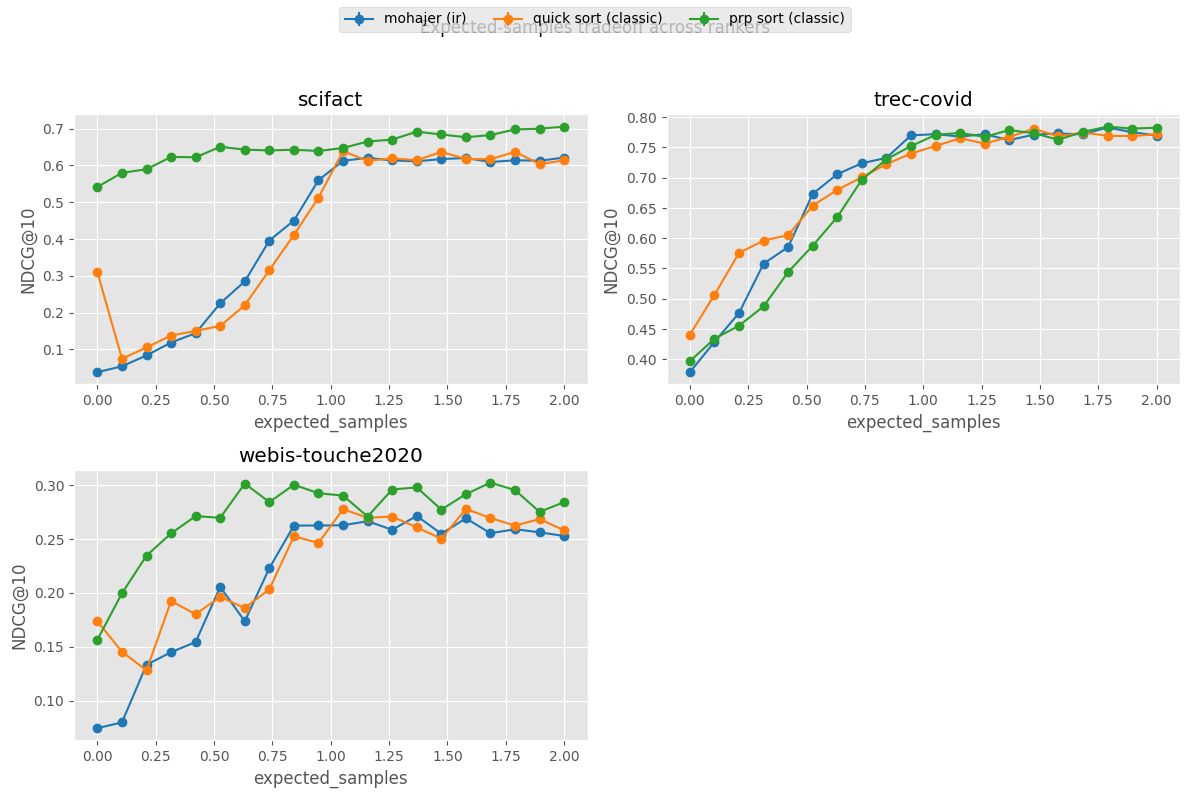

In [5]:

colors = plt.cm.tab10.colors
unique_ds = sorted(tradeoff_df["dataset"].unique())
fig, axes = plt.subplots(
    nrows=(len(unique_ds) + 1) // 2,
    ncols=2 if len(unique_ds) > 1 else 1,
    figsize=(12, 4 * ((len(unique_ds) + 1) // 2)),
    squeeze=False,
)

for idx, ds in enumerate(unique_ds):
    ax = axes[idx // 2][idx % 2]
    ds_data = tradeoff_df[tradeoff_df["dataset"] == ds]
    stats = (
        ds_data.groupby(["ranker", "expected_samples"])["NDCG@10"]
        .agg(["mean", "std"])
        .reset_index()
    )
    for ridx, ranker_name in enumerate(RANKERS):
        sub = stats[stats["ranker"] == ranker_name]
        if sub.empty:
            continue
        color = colors[ridx % len(colors)]
        ax.errorbar(
            sub["expected_samples"],
            sub["mean"],
            yerr=sub["std"],
            fmt="-o",
            label=ranker_name,
            color=color,
        )
    ax.set_title(ds)
    ax.set_xlabel("expected_samples")
    ax.set_ylabel("NDCG@10")
    ax.grid(True)

# Hide any unused subplots
for j in range(len(unique_ds), axes.size):
    fig.delaxes(axes.flatten()[j])

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(RANKERS), 4))
fig.suptitle("Expected-samples tradeoff across rankers")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



- Datasets and light-mode filtering come from `config/beir_eval.json`.
- Adjust `SEEDS` and `EXPECTED_SAMPLES` to explore stability vs. sampling budget; more seeds improve robustness but increase runtime.
- RANKERS currently include Mohajer, Quick Sort (Classic), and PRP Sort (Classic); add/remove names in `RANKERS` as needed.
